# Dynamic Traffic Signal Control (Modular, Midday)


Steps of Algorithm:
1. Setup & Utilities  
2. Upload Video & Extract Frames (fixed duplication issue)  
3. Preprocess Frames  
   a) Auto-Labeling Frames
   b) Training Yolov8 model
4. Run YOLO Inference (vehicle detection)  
5. Evaluation of trained model
6. Inference with custom-model
7. Vehicle Density Calculation  
8. Dynamic Signal Control (density + time-of-day rules)
9. Mutli-Lane Approach (4- way Intersection)  



### **1) Setup & Utilities**

In [ ]:
!pip -q install ultralytics opencv-python-headless==4.10.0.84 opencv-python numpy pandas matplotlib tqdm

import os, io, cv2, sys, json, glob, math, time, shutil, logging, zipfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
from ultralytics import YOLO

try:
    from google.colab import files
except Exception:
    files = None

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s",
                    filename="pipeline.log", filemode="w")
print("Environment ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Environment ready.


### **2) Upload Video & Extract Frames**

In [ ]:
#@title Configure extraction
from pathlib import Path
import cv2, zipfile
from tqdm import tqdm
import matplotlib.pyplot as plt

OUTPUT_BASE = Path("/content")
FRAMES_DIR = OUTPUT_BASE / "frames"
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

SAVE_EVERY_NTH = 1  #@param {type:"slider", min:1, max:10, step:1}
DISPLAY_PREVIEW = False  #@param {type:"boolean"}
MAX_PREVIEW = 50  #@param {type:"slider", min:10, max:200, step:10}

def extract_frames(video_path: str, out_dir: Path, save_every_nth: int = 1,
                   show_preview: bool = False, max_preview: int = 50):
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS); total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Video FPS: {fps:.2f}, Total Frames: {total}")
    frame_idx, saved = 0, 0
    pbar = tqdm(total=total, desc="Extracting frames")
    while True:
        ok, frame = cap.read()
        if not ok: break
        if frame_idx % save_every_nth == 0:
            fname = f"frame_{saved:06d}.jpg"
            cv2.imwrite(str(out_dir / fname), frame)
            saved += 1
            if show_preview and saved <= max_preview:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(4,3)); plt.imshow(rgb); plt.axis("off"); plt.title(f"Preview {saved}"); plt.show()
        frame_idx += 1; pbar.update(1)
    pbar.close(); cap.release()
    print(f"Saved {saved} frames to {out_dir}")
    zip_path = out_dir.parent / "frames.zip"
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for img in sorted(out_dir.glob("*.jpg")):
            zf.write(str(img), arcname=f"frames/{img.name}")
    print(f"Created zip: {zip_path}")
    return saved, zip_path

if files is not None:
    print("Upload your video file (.mp4, .avi, etc.)")
    uploaded = files.upload()
    assert len(uploaded) >= 1, "No file uploaded."
    video_path = list(uploaded.keys())[0]
else:
    video_path = "/content/sample_data/sample-video.mp4"
    print(f"Using fallback video path: {video_path}")

saved_count, zip_path = extract_frames(video_path, FRAMES_DIR, SAVE_EVERY_NTH, DISPLAY_PREVIEW, MAX_PREVIEW)
print(f"Frames saved: {saved_count}")

Upload your video file (.mp4, .avi, etc.)


Saving Sample 1.mp4 to Sample 1.mp4
Video FPS: 59.94, Total Frames: 900


Extracting frames: 100%|██████████| 900/900 [00:03<00:00, 236.79it/s]


Saved 900 frames to /content/frames
Created zip: /content/frames.zip
Frames saved: 900


### **3) Preprocess Frames**

In [ ]:
import cv2, glob, numpy as np
from pathlib import Path
from tqdm import tqdm

PROCESSED_DIR = Path("/content/processed_frames")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def preprocess_frame(image, target_size=(640, 640), apply_clahe=True, blur_kernel=(3, 3)):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]; tw, th = target_size
    scale = min(tw / w, th / h); nw, nh = int(w*scale), int(h*scale)
    resized = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
    padded = np.zeros((th, tw, 3), dtype=np.uint8)
    pad_top = (th - nh)//2; pad_left = (tw - nw)//2
    padded[pad_top:pad_top+nh, pad_left:pad_left+nw] = resized
    if apply_clahe:
        clahe = cv2.createCLAHE(2.0, (8,8))
        for i in range(3): padded[:,:,i] = clahe.apply(padded[:,:,i])
    if blur_kernel and blur_kernel != (0,0):
        padded = cv2.GaussianBlur(padded, blur_kernel, 0)
    return cv2.cvtColor(padded, cv2.COLOR_RGB2BGR)

def preprocess_frames(input_dir: Path, output_dir: Path, target_size=(640, 640)):
    imgs = sorted(glob.glob(str(input_dir / "*.jpg")))
    for fp in tqdm(imgs, desc="Preprocessing frames"):
        im = cv2.imread(fp)
        if im is None: continue
        out = preprocess_frame(im, target_size=target_size)
        cv2.imwrite(str(output_dir / Path(fp).name), out)

preprocess_frames(FRAMES_DIR, PROCESSED_DIR, (640, 640))
print("Preprocessing complete.")

Preprocessing frames: 100%|██████████| 900/900 [00:20<00:00, 44.02it/s]


Preprocessing complete.


**3a) Auto-Labelling Frames with Pretrained yolo (Pseudo-Labeling)**

In [ ]:
# --------------------------
# 3b) Auto-Label Frames with Pretrained YOLO (Pseudo-Labeling)
# --------------------------
# Install compatible versions of libraries
# !pip install ultralytics==8.2.42 # Commented out to use version from setup cell

from sklearn.model_selection import train_test_split
import shutil
import glob
from tqdm import tqdm
from ultralytics import YOLO
from pathlib import Path

# Directories
DATASET_DIR = Path("/content/dataset")
IMG_DIR = DATASET_DIR / "images"
LBL_DIR = DATASET_DIR / "labels"

for split in ["train","val","test"]:
    (IMG_DIR/split).mkdir(parents=True, exist_ok=True)
    (LBL_DIR/split).mkdir(parents=True, exist_ok=True)

# Use pretrained YOLO to generate labels
auto_model = YOLO("yolov8n.pt")  # small model for speed
all_imgs = sorted(glob.glob(str(PROCESSED_DIR/"*.jpg")))

records = []
for img_path in tqdm(all_imgs, desc="Auto-labeling images"):
    results = auto_model(img_path, conf=0.25, iou=0.45, verbose=False)[0]

    # Save YOLO-format label file
    h, w = results.orig_img.shape[:2]
    lbl_path = str(img_path).replace("processed_frames", "dataset/labels/all").replace(".jpg", ".txt")
    Path(lbl_path).parent.mkdir(parents=True, exist_ok=True)

    with open(lbl_path, "w") as f:
        for box, cls in zip(results.boxes.xywhn, results.boxes.cls):
            x,y,bx,by = box.tolist()
            cls_id = int(cls)
            f.write(f"{cls_id} {x:.6f} {y:.6f} {bx:.6f} {by:.6f}\n")

    records.append(img_path)

print(f"Generated labels for {len(records)} images.")

# ===========================
# Auto-split train/val/test
# ===========================
train_imgs, test_imgs = train_test_split(records, test_size=0.2, random_state=42)
train_imgs, val_imgs = train_test_split(train_imgs, test_size=0.2, random_state=42)

splits = {"train": train_imgs, "val": val_imgs, "test": test_imgs}

for split, imgs in splits.items():
    for img in imgs:
        img_name = Path(img).name
        lbl_name = img_name.replace(".jpg", ".txt")

        # Copy image
        shutil.copy(img, IMG_DIR/split/img_name)

        # Copy label
        lbl_src = str(img).replace("processed_frames", "dataset/labels/all").replace(".jpg",".txt")
        if Path(lbl_src).exists():
            shutil.copy(lbl_src, LBL_DIR/split/lbl_name)

print("✅ Dataset ready in YOLO format: /content/dataset")

Auto-labeling images: 100%|██████████| 900/900 [04:01<00:00,  3.72it/s]


Generated labels for 900 images.
✅ Dataset ready in YOLO format: /content/dataset


**3b) Training Yolov8 model**

In [ ]:
from pathlib import Path

DATASET_DIR = Path("/content/dataset")

data_yaml_content = """path: /content/dataset
train: images/train
val: images/val
test: images/test

# Note: IDs must match YOLOv8 COCO pretrained class order
nc: 22
names: [
 'car', 'bus','truck', 'rickshaw', 'three-wheeler(cng)', 'motorbike', 'bicycle','garbagevan','human hauler', 'microbus','minivan', 'pickup', 'army tank', 'scooter', 'suv', 'yellow taxi', 'van', 'three-wheel cart', 'ambulance','policecar','firetruck','pedestrian'
]
"""

(DATASET_DIR / "data.yaml").write_text(data_yaml_content)

print(f"Created data.yaml at: {DATASET_DIR / 'data.yaml'}")

Created data.yaml at: /content/dataset/data.yaml


In [ ]:
model = YOLO("yolov8n.pt")  # start from pretrained
model.train(
    data="/content/dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

Ultralytics 8.3.195 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 5, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eb663e973b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

### **4) Run YOLO Inference (Vehicle Detection)**

In [ ]:
custom_model = YOLO("/content/runs/detect/train/weights/best.pt")

# Run inference on processed frames
out_dir = Path("/content/custom_detections")
out_dir.mkdir(parents=True, exist_ok=True)

for img in sorted(glob.glob(str(PROCESSED_DIR/"*.jpg"))[:50]):  # first 50 frames
    results = custom_model(img, conf=0.25)[0]
    annotated = results.plot()
    cv2.imwrite(str(out_dir/Path(img).name), annotated)

print("✅ Inference complete, results in /content/custom_detections")


image 1/1 /content/processed_frames/frame_000001.jpg: 640x640 6 cars, 23 trucks, 3 rickshaws, 10 motorbikes, 636.4ms
Speed: 21.5ms preprocess, 636.4ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000013.jpg: 640x640 4 cars, 25 trucks, 2 rickshaws, 11 motorbikes, 225.7ms
Speed: 5.8ms preprocess, 225.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000041.jpg: 640x640 4 cars, 26 trucks, 2 rickshaws, 10 motorbikes, 3 garbagevans, 219.7ms
Speed: 2.8ms preprocess, 219.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000059.jpg: 640x640 6 cars, 27 trucks, 3 rickshaws, 10 motorbikes, 3 garbagevans, 221.6ms
Speed: 3.2ms preprocess, 221.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000060.jpg: 640x640 7 cars, 28 trucks, 3 rickshaws, 10 motorbi

## **5) Evaluation of the trained model**

Latest run folder: /content/runs/detect/train


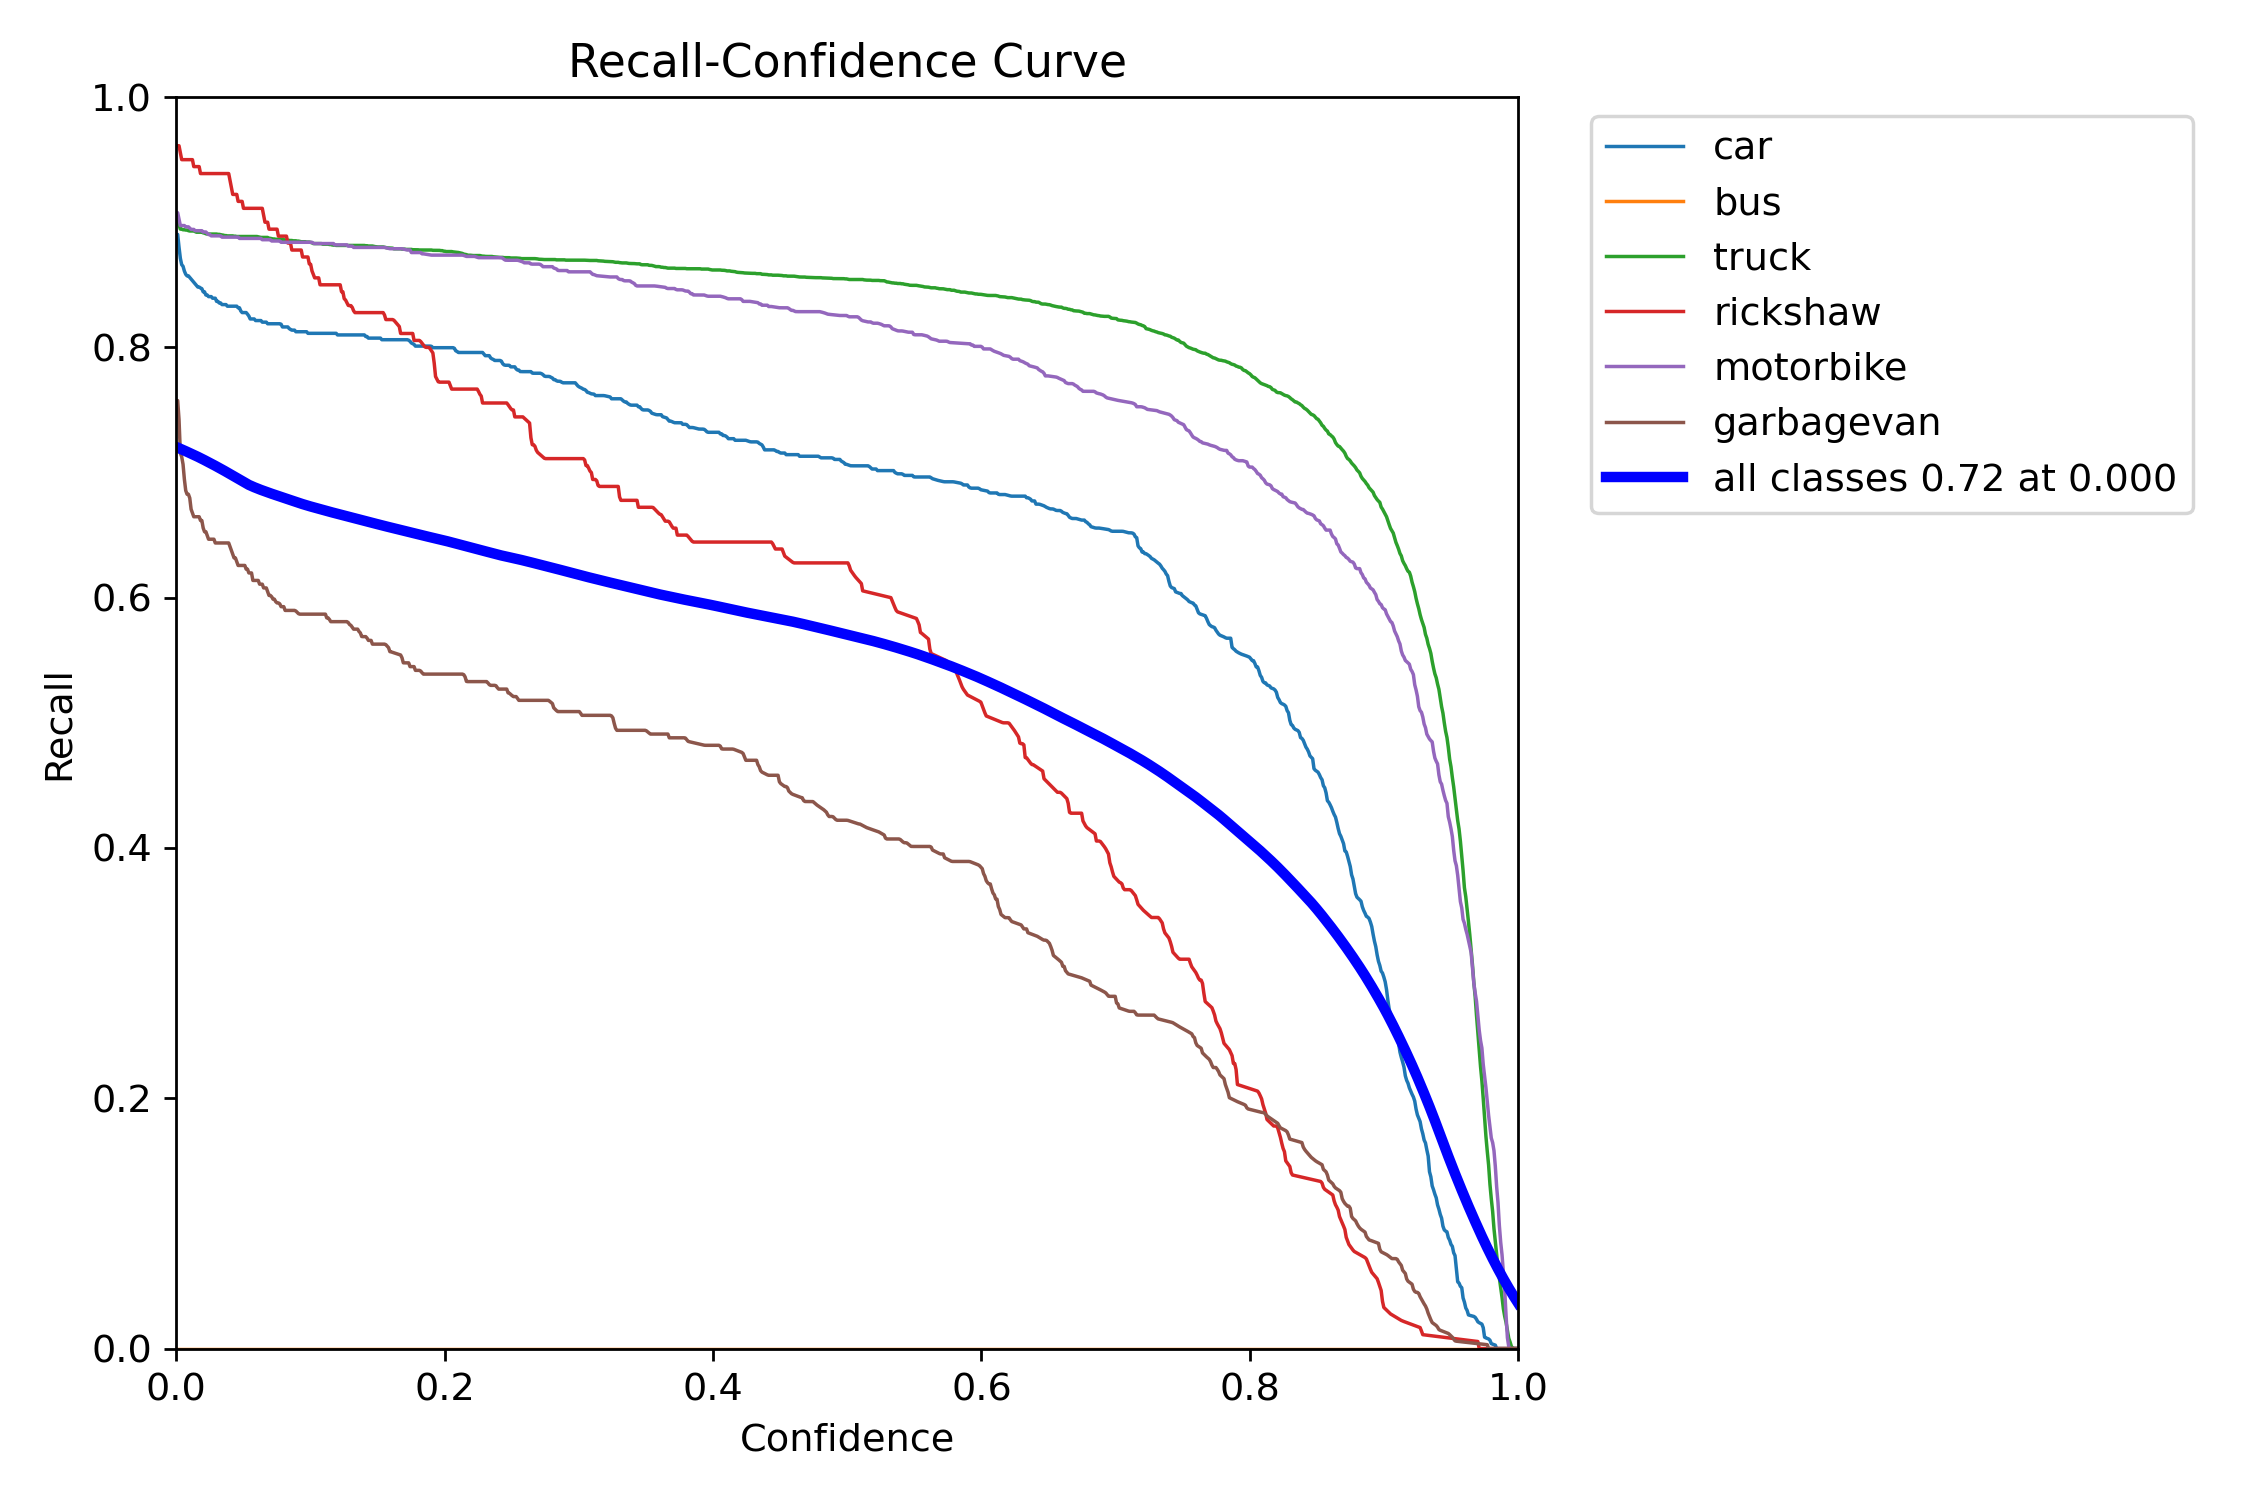

In [ ]:
from IPython.display import Image
from pathlib import Path

# Find the most recent run folder
runs_dir = Path("/content/runs/detect")
latest_run = max(runs_dir.glob("train*"), key=lambda p: p.stat().st_mtime)
print("Latest run folder:", latest_run)

# Show evaluation plots
Image(filename=str(latest_run / "/content/runs/detect/train/confusion_matrix.png"))
Image(filename=str(latest_run / "/content/runs/detect/train/BoxPR_curve.png"))
Image(filename=str(latest_run / "/content/runs/detect/train/BoxF1_curve.png"))
Image(filename=str(latest_run / "/content/runs/detect/train/BoxR_curve.png"))



## **6. Inference with Custom Model**

In [ ]:
# --------------------------
# Inference with Custom Model
# --------------------------
import cv2, glob
from pathlib import Path

PROCESSED_DIR = Path("/content/processed_frames")
CUSTOM_DETECTIONS_DIR = Path("/content/custom_detections")
CUSTOM_DETECTIONS_DIR.mkdir(parents=True, exist_ok=True)

# Run inference on first 50 frames
for img in sorted(glob.glob(str(PROCESSED_DIR/"*.jpg"))[:50]):
    results = custom_model(img, conf=0.25)[0]
    annotated = results.plot()
    cv2.imwrite(str(CUSTOM_DETECTIONS_DIR/Path(img).name), annotated)

print("✅ Annotated detections saved in:", CUSTOM_DETECTIONS_DIR)



image 1/1 /content/processed_frames/frame_000001.jpg: 640x640 6 cars, 23 trucks, 3 rickshaws, 10 motorbikes, 230.6ms
Speed: 4.8ms preprocess, 230.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000013.jpg: 640x640 4 cars, 25 trucks, 2 rickshaws, 11 motorbikes, 217.9ms
Speed: 3.2ms preprocess, 217.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000041.jpg: 640x640 4 cars, 26 trucks, 2 rickshaws, 10 motorbikes, 3 garbagevans, 217.7ms
Speed: 3.2ms preprocess, 217.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000059.jpg: 640x640 6 cars, 27 trucks, 3 rickshaws, 10 motorbikes, 3 garbagevans, 221.0ms
Speed: 2.8ms preprocess, 221.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000060.jpg: 640x640 7 cars, 28 trucks, 3 rickshaws, 10 motorbik

In [ ]:
from ultralytics import YOLO
from pathlib import Path

EVAL_DIR = Path("/content/evaluation_results"); EVAL_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR = Path("/content/dataset")
yaml_path = DATASET_DIR / "data.yaml"

def has_labels(split):
    return any((DATASET_DIR/"labels"/split).glob("*.txt"))

if yaml_path.exists() and (has_labels("val") or has_labels("test") or has_labels("train")):
    print("Found data.yaml and labels -> running Ultralytics validation")
    model_for_eval = YOLO("yolov8n.pt")  # or your custom weights
    results = model_for_eval.val(data=str(yaml_path), imgsz=640, conf=0.25, iou=0.6)
    rd = results.results_dict
    print("Validation metrics:")
    for k, v in rd.items():
        print(f"  {k}: {v}")
else:
    print("No labeled dataset found. Skipping mAP/PR evaluation.")
    print("Review qualitative results in /content/detections and counts CSV.")

Found data.yaml and labels -> running Ultralytics validation
Ultralytics 8.3.195 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1290.7±847.1 MB/s, size: 101.3 KB)
val: Scanning /content/dataset/labels/val.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 177.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 0.2it/s 40.4s
                   all        144       6348      0.828      0.778      0.828      0.793
                person        144        784      0.793      0.787      0.857      0.808
               bicycle          1          1          1          1      0.995      0.995
                   car        144       4075      0.965      0.848      0.919      0.906
            motorcycle        105        180      0.771      0.728      0

## **7) Vehicle Density Calculation**

In [ ]:
# --------------------------
# Vehicle Counts & Density from Custom Model
# --------------------------
import pandas as pd

VEHICLE_CLASSES = {"car", "bus","truck", "rickshaw", "three-wheeler(cng)", "motorbike", "bicycle","garbagevan","human hauler", "microbus","minivan", "pickup", "army tank", "scooter", "suv", "yellow taxi", "van", "three-wheel cart", "ambulance","policecar","firetruck"}

records = []
for fp in sorted(glob.glob(str(PROCESSED_DIR/"*.jpg"))[:50]):
    res = custom_model(fp, conf=0.25)[0]
    names = res.names
    cls = res.boxes.cls.cpu().numpy() if res.boxes is not None else []
    counts = {}
    for c in cls:
        name = names.get(int(c), str(int(c)))
        if name in VEHICLE_CLASSES:
            counts[name] = counts.get(name, 0) + 1
    total = sum(counts.values())
    records.append({"frame": Path(fp).name, **{f"count_{k}": v for k,v in counts.items()}, "count_total": total})

df_counts = pd.DataFrame(records).fillna(0)

DETECTIONS_DIR = Path("/content/custom_detections")
DETECTIONS_DIR.mkdir(parents=True, exist_ok=True) # Ensure directory exists

df_counts.to_csv(DETECTIONS_DIR / "vehicle_counts.csv", index=False)

# Compute density (here = total vehicles / fixed area, normalize by 20 as example)
df_counts["density"] = df_counts["count_total"] / 20.0
df_counts.to_csv(DETECTIONS_DIR / "vehicle_density.csv", index=False)

print("✅ Saved counts and density to CSVs.")
display(df_counts.head())


image 1/1 /content/processed_frames/frame_000001.jpg: 640x640 6 cars, 23 trucks, 3 rickshaws, 10 motorbikes, 347.5ms
Speed: 4.7ms preprocess, 347.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000013.jpg: 640x640 4 cars, 25 trucks, 2 rickshaws, 11 motorbikes, 314.1ms
Speed: 3.7ms preprocess, 314.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000041.jpg: 640x640 4 cars, 26 trucks, 2 rickshaws, 10 motorbikes, 3 garbagevans, 338.4ms
Speed: 4.4ms preprocess, 338.4ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000059.jpg: 640x640 6 cars, 27 trucks, 3 rickshaws, 10 motorbikes, 3 garbagevans, 335.1ms
Speed: 3.7ms preprocess, 335.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/processed_frames/frame_000060.jpg: 640x640 7 cars, 28 trucks, 3 rickshaws, 10 motorbik

,frame,count_motorbike,count_truck,count_car,count_rickshaw,count_total,count_garbagevan,density
0,frame_000001.jpg,10,23,6,3.0,42,0.0,2.10
1,frame_000013.jpg,11,25,4,2.0,42,0.0,2.10
2,frame_000041.jpg,10,26,4,2.0,45,3.0,2.25
3,frame_000059.jpg,10,27,6,3.0,49,3.0,2.45
4,frame_000060.jpg,10,28,7,3.0,51,3.0,2.55


Saved density CSV to: /content/custom_detections/vehicle_density.csv


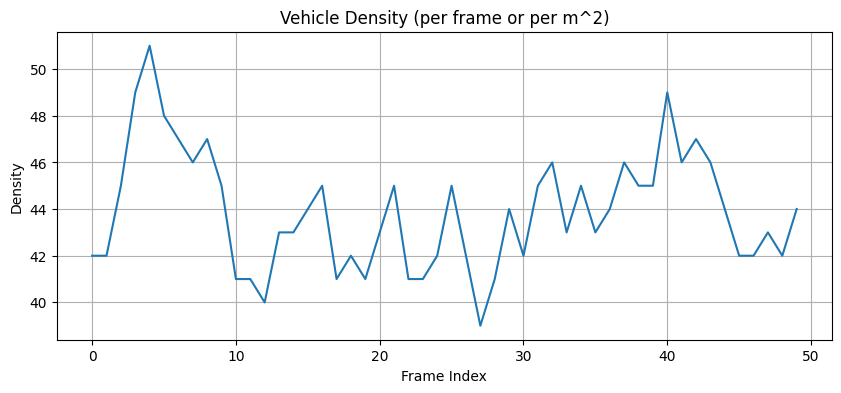

Average density: 43.9


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DETECTIONS_DIR = Path("/content/custom_detections")
DETECTIONS_DIR.mkdir(parents=True, exist_ok=True) # Create the directory

counts_csv = DETECTIONS_DIR / "vehicle_counts.csv"
df_counts = pd.read_csv(counts_csv) if counts_csv.exists() else pd.DataFrame(columns=["frame","count_total"])

AREA_M2 = None  # e.g., 120.0

density_records = []
for _, row in df_counts.iterrows():
    frame = row["frame"]; count_total = int(row["count_total"])
    density = count_total if AREA_M2 is None else count_total / AREA_M2
    density_records.append({"frame": frame, "vehicles": count_total, "density": density})

df_density = pd.DataFrame(density_records)
density_csv = DETECTIONS_DIR / "vehicle_density.csv"
df_density.to_csv(density_csv, index=False)
print(f"Saved density CSV to: {density_csv}")

if not df_density.empty:
    plt.figure(figsize=(10,4))
    plt.plot(range(len(df_density)), df_density["density"])
    plt.title("Vehicle Density (per frame or per m^2)")
    plt.xlabel("Frame Index"); plt.ylabel("Density"); plt.grid(True); plt.show()

print("Average density:", float(df_density["density"].mean()) if not df_density.empty else 0.0)

### **8) Dynamic Signal Control (Density + Time of Day)**

In [ ]:
# ----------------------
# 8) Dynamic Signal Control (Density + Time of Day with Manual Selector)
# ----------------------

# Define traffic light states
class TrafficLightState:
    RED = "RED"
    GREEN = "GREEN"
    YELLOW = "YELLOW"

# Time-period configuration (tunable)
TIME_PERIODS = {
    "morning_peak":  {"hours": (6, 10),  "min_green": 50, "max_green": 70, "density_threshold": 12, "red_duration": 40},
    "midday":        {"hours": (10, 16), "min_green": 40, "max_green": 60, "density_threshold": 8,  "red_duration": 30},
    "evening_peak":  {"hours": (16, 21), "min_green": 50, "max_green": 70, "density_threshold": 12, "red_duration": 40},
    "night":         {"hours": (21, 6),  "min_green": 5,  "max_green": 20, "density_threshold": 4,  "red_duration": 20},
}

# Function to calculate green duration based on density and config
def calculate_green_duration(density, cfg):
    mn, mx, th = cfg["min_green"], cfg["max_green"], cfg["density_threshold"]
    if density <= 0:
        return mn
    ratio = min(density/th, 1.0)
    return int(round(mn + (mx - mn) * ratio))

# Function to build the control schedule
def control_schedule(avg_density, period_key="midday", yellow_duration=3):
    cfg = TIME_PERIODS[period_key]
    green = calculate_green_duration(avg_density, cfg)
    red = cfg["red_duration"]

    schedule = [
        {"t": 0, "state": TrafficLightState.GREEN,  "duration": green, "period": period_key},
        {"t": green, "state": TrafficLightState.YELLOW, "duration": yellow_duration, "period": period_key},
        {"t": green+yellow_duration, "state": TrafficLightState.RED, "duration": red, "period": period_key},
    ]
    return schedule, cfg

# ==========================
# USER SELECT TIME PERIOD
# ==========================
#@title Select the time-of-day for this video
video_time_period = "midday"  #@param ["morning_peak", "midday", "evening_peak", "night"]

# Load density results
from pathlib import Path
import pandas as pd

DETECTIONS_DIR = Path("/content/detections")
df_density = pd.read_csv(DETECTIONS_DIR / "vehicle_density.csv") if (DETECTIONS_DIR/"vehicle_density.csv").exists() else pd.DataFrame(columns=["density"])
avg_density = float(df_density["density"].mean()) if not df_density.empty else 0.0

# Build schedule
schedule, cfg = control_schedule(avg_density, video_time_period)

print(f"Video context: {video_time_period} -> cfg={cfg}")
print(f"Average density: {avg_density:.2f}")
print("Proposed cycle:")
t = 0
for s in schedule:
    print(f" t={s['t']:>3}s  {s['state']:<6}  for {s['duration']:>2}s")
    t += s["duration"]
print(f"Total cycle length: {t}s")


Video context: midday -> cfg={'hours': (10, 16), 'min_green': 40, 'max_green': 60, 'density_threshold': 8, 'red_duration': 30}
Average density: 0.00
Proposed cycle:
 t=  0s  GREEN   for 40s
 t= 40s  YELLOW  for  3s
 t= 43s  RED     for 30s
Total cycle length: 73s


### **9.Multi-Approach Dynamic Signal Schedule (4-way Intersection)**

In [ ]:
# --------------------------
# 2) ROI Utilities (Lane Division)
# --------------------------
import cv2, glob, numpy as np
from pathlib import Path

PROCESSED_DIR = Path("/content/processed_frames")

def make_grid_rois(image_shape, n_lanes=4, orientation='vertical'):
    """Auto-split the frame into ROIs (lanes)."""
    h, w = image_shape[:2]
    rois = {}
    if orientation == 'vertical':
        step = w / n_lanes
        for i in range(n_lanes):
            x1, x2 = int(i*step), int((i+1)*step)
            rois[f"lane_{i}"] = (x1, 0, x2, h)
    else:
        step = h / n_lanes
        for i in range(n_lanes):
            y1, y2 = int(i*step), int((i+1)*step)
            rois[f"lane_{i}"] = (0, y1, w, y2)
    return rois

def point_in_roi(x, y, roi):
    x1,y1,x2,y2 = roi
    return (x1 <= x <= x2) and (y1 <= y <= y2)


In [ ]:
# --------------------------
# 3) Vehicle Counts per ROI using Trained Model
# --------------------------
import pandas as pd
from tqdm import tqdm

CUSTOM_ROI_DIR = Path("/content/custom_detections_rois")
CUSTOM_ROI_DIR.mkdir(parents=True, exist_ok=True)

VEHICLE_CLASSES = {"car","bus","truck","motorcycle","bicycle","person"}

# Sample image for ROI creation
proc_imgs = sorted(glob.glob(str(PROCESSED_DIR/"*.jpg")))
if not proc_imgs:
    raise RuntimeError("No processed frames found. Run preprocessing first.")

sample_img = cv2.imread(proc_imgs[0])
rois = make_grid_rois(sample_img.shape, n_lanes=4, orientation='vertical')

# Detect & count
records = []
for idx, fp in enumerate(tqdm(proc_imgs[:50], desc="Counting vehicles per ROI")):  # limit to 50 frames
    res = custom_model(fp, conf=0.25)[0]
    names = res.names
    boxes = res.boxes.xyxy.cpu().numpy() if res.boxes is not None else []
    clses = res.boxes.cls.cpu().numpy() if res.boxes is not None else []

    counts = {k: 0 for k in rois.keys()}
    for i, box in enumerate(boxes):
        x1,y1,x2,y2 = map(int, box)
        cx, cy = int((x1+x2)/2), int((y1+y2)/2)
        cls_name = names.get(int(clses[i]), str(int(clses[i])))
        if cls_name in VEHICLE_CLASSES:
            for rname, roi in rois.items():
                if point_in_roi(cx, cy, roi):
                    counts[rname] += 1
                    break
    records.append({"frame": Path(fp).name, **counts})

df_lane_counts = pd.DataFrame(records).fillna(0)
df_lane_counts.to_csv(CUSTOM_ROI_DIR/"lane_counts.csv", index=False)

# Compute density (normalize by threshold, e.g., divide by 20)
df_lane_counts["density"] = df_lane_counts.drop(columns="frame").sum(axis=1) / 20.0
df_lane_counts.to_csv(CUSTOM_ROI_DIR/"lane_density.csv", index=False)

print("✅ Saved lane counts and densities in:", CUSTOM_ROI_DIR)
df_lane_counts.head()


Counting vehicles per ROI:   0%|          | 0/50 [00:00<?, ?it/s]


image 1/1 /content/processed_frames/frame_000000.jpg: 640x640 6 cars, 23 trucks, 4 rickshaws, 10 motorbikes, 221.4ms
Speed: 4.1ms preprocess, 221.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


Counting vehicles per ROI:   2%|▏         | 1/50 [00:00<00:11,  4.20it/s]


image 1/1 /content/processed_frames/frame_000001.jpg: 640x640 6 cars, 23 trucks, 3 rickshaws, 10 motorbikes, 219.0ms
Speed: 2.8ms preprocess, 219.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


Counting vehicles per ROI:   4%|▍         | 2/50 [00:00<00:11,  4.23it/s]

...

from matplotlib import pyplot as plt
_df_32['lane_3'].plot(kind='line', figsize=(8, 4), title='lane_3')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_33['density'].plot(kind='line', figsize=(8, 4), title='density')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_34['frame'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_34, x='lane_1', y='frame', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_35['frame'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_35, x='lane_3', y='frame', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_36['frame'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_36, x='density', y='frame', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
# --------------------------
# 4) Multi-Approach Dynamic Signal Schedule
# --------------------------
import json

# Time-period config
TIME_PERIODS = {
    "morning_peak":  {"min_green": 50, "max_green": 70, "density_threshold": 12, "red_duration": 40},
    "midday":        {"min_green": 40, "max_green": 60, "density_threshold": 8,  "red_duration": 30},
    "evening_peak":  {"min_green": 50, "max_green": 70, "density_threshold": 12, "red_duration": 40},
    "night":         {"min_green": 5,  "max_green": 20, "density_threshold": 4,  "red_duration": 20},
}

#@title Select the time-of-day for this video
video_time_period = "midday"  #@param ["morning_peak", "midday", "evening_peak", "night"]

cfg = TIME_PERIODS[video_time_period]

def calculate_green_duration(density, cfg):
    mn, mx, th = cfg["min_green"], cfg["max_green"], cfg["density_threshold"]
    if density <= 0: return mn
    ratio = min(density/th, 1.0)
    return int(round(mn + (mx - mn) * ratio))

# Map lanes → approaches
approach_map = {
    "A": ["lane_0"],
    "B": ["lane_1"],
    "C": ["lane_2"],
    "D": ["lane_3"]
}

# Compute average density per lane
avg_lane_density = {ln: float(df_lane_counts[ln].mean()) if ln in df_lane_counts else 0.0
                    for ln in df_lane_counts.columns if ln not in ["frame","density"]}

# Compute green per lane
per_lane_green = {ln: calculate_green_duration(d, cfg) for ln,d in avg_lane_density.items()}

# Per-approach green = max of its lanes
approach_green = {a: max([per_lane_green.get(ln, cfg["min_green"]) for ln in lanes], default=cfg["min_green"])
                  for a,lanes in approach_map.items()}

# Build schedule
YELLOW = 3
ALL_RED = 2
phases, t = [], 0
for a in sorted(approach_map.keys()):
    g = approach_green[a]
    phases.append({"approach": a, "t": t, "state": "GREEN", "duration": g, "period": video_time_period})
    t += g
    phases.append({"approach": a, "t": t, "state": "YELLOW", "duration": YELLOW, "period": video_time_period})
    t += YELLOW
    phases.append({"approach": a, "t": t, "state": "ALL_RED", "duration": ALL_RED, "period": video_time_period})
    t += ALL_RED

# Print summary
print(f"\nVideo context: {video_time_period}")
print(f"Average lane densities: {avg_lane_density}")
print(f"Per-lane green: {per_lane_green}")
print(f"Per-approach green: {approach_green}")
print(f"Proposed cycle length: {t}s")
for ph in phases:
    print(f" t={ph['t']:>3}s  Approach {ph['approach']} {ph['state']:<7} for {ph['duration']:>2}s")

# Save schedule
pd.DataFrame(phases).to_csv(CUSTOM_ROI_DIR/"phase_schedule.csv", index=False)
(Path(CUSTOM_ROI_DIR)/"summary.json").write_text(json.dumps({
    "time_period": video_time_period,
    "avg_lane_density": avg_lane_density,
    "per_lane_green": per_lane_green,
    "per_approach_green": approach_green,
    "total_cycle_s": t
}, indent=2))
print("✅ Schedule saved to:", CUSTOM_ROI_DIR)



Video context: midday
Average lane densities: {'lane_0': 6.88, 'lane_1': 14.3, 'lane_2': 3.74, 'lane_3': 5.18}
Per-lane green: {'lane_0': 57, 'lane_1': 60, 'lane_2': 49, 'lane_3': 53}
Per-approach green: {'A': 57, 'B': 60, 'C': 49, 'D': 53}
Proposed cycle length: 239s
 t=  0s  Approach A GREEN   for 57s
 t= 57s  Approach A YELLOW  for  3s
 t= 60s  Approach A ALL_RED for  2s
 t= 62s  Approach B GREEN   for 60s
 t=122s  Approach B YELLOW  for  3s
 t=125s  Approach B ALL_RED for  2s
 t=127s  Approach C GREEN   for 49s
 t=176s  Approach C YELLOW  for  3s
 t=179s  Approach C ALL_RED for  2s
 t=181s  Approach D GREEN   for 53s
 t=234s  Approach D YELLOW  for  3s
 t=237s  Approach D ALL_RED for  2s
✅ Schedule saved to: /content/custom_detections_rois


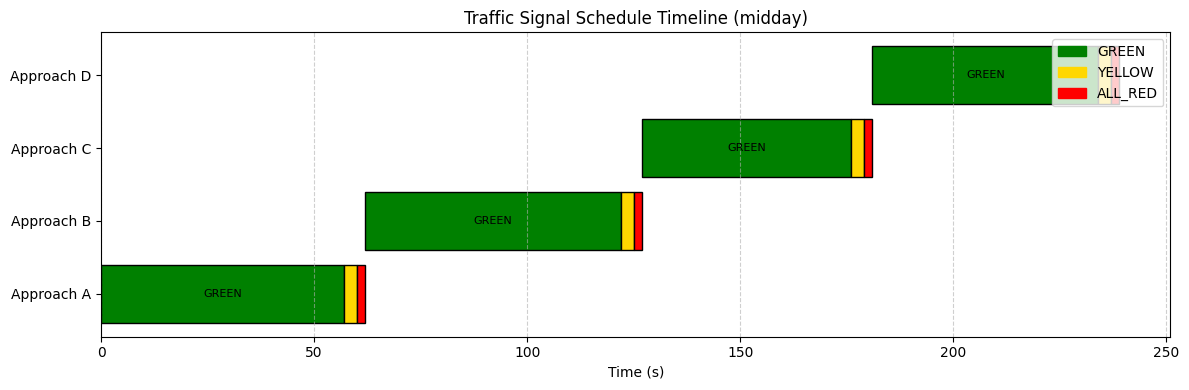

In [ ]:
# --------------------------
# Visualize Multi-Approach Schedule as Timeline
# --------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Map states to colors
color_map = {
    "GREEN": "green",
    "YELLOW": "gold",
    "ALL_RED": "red"
}

# Build timeline plot
fig, ax = plt.subplots(figsize=(12, 4))

yticks = []
ylabels = []
for i, app in enumerate(sorted(approach_map.keys())):
    y = i
    ylabels.append(f"Approach {app}")
    yticks.append(y)

    for ph in phases:
        if ph["approach"] == app:
            ax.barh(
                y=y,
                width=ph["duration"],
                left=ph["t"],
                color=color_map.get(ph["state"], "gray"),
                edgecolor="black"
            )
            # Label inside bar if enough space
            if ph["duration"] > 4:
                ax.text(
                    ph["t"] + ph["duration"]/2,
                    y,
                    ph["state"],
                    ha="center", va="center", fontsize=8, color="black"
                )

# Format axes
ax.set_xlabel("Time (s)")
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_title(f"Traffic Signal Schedule Timeline ({video_time_period})")
ax.grid(True, axis="x", linestyle="--", alpha=0.6)

# Legend
legend_handles = [mpatches.Patch(color=c, label=s) for s,c in color_map.items()]
ax.legend(handles=legend_handles, loc="upper right")

plt.tight_layout()
plt.show()


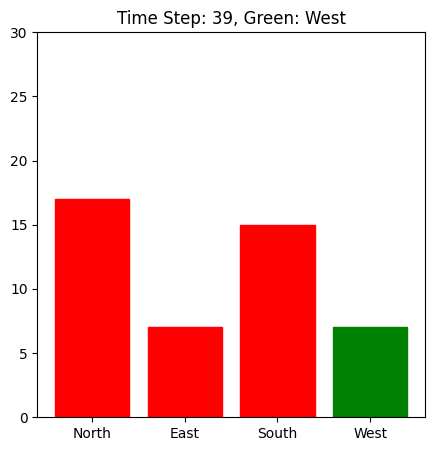

In [ ]:
# ===============================
# Traffic Signal Animation (Video)
# ===============================
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Example: define lanes
lanes = ["North", "East", "South", "West"]

# Initialize figure
fig, ax = plt.subplots(figsize=(5,5))
ax.set_ylim(0, 30)  # adjust max density value
bars = ax.bar(lanes, np.zeros(len(lanes)), color="red")

# This function will be called at each frame
def update(frame):
    # Example: random traffic density (replace with your actual logic if available)
    new_data = np.random.randint(5, 25, size=len(lanes))

    # Update bar heights
    for bar, h in zip(bars, new_data):
        bar.set_height(h)

    # Cycle signal (1 lane green at a time, others red)
    green_lane = frame % len(lanes)
    for i, bar in enumerate(bars):
        if i == green_lane:
            bar.set_color("green")
        else:
            bar.set_color("red")
    ax.set_title(f"Time Step: {frame}, Green: {lanes[green_lane]}")

# Animate (frames = number of steps in the simulation)
ani = animation.FuncAnimation(fig, update, frames=40, repeat=True, interval=500)

# Save as mp4 video
ani.save("traffic_simulation.mp4", writer="ffmpeg")

plt.show()
